In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_to_data = '../data/spotify_data/'

import os
for dirname, _, filenames in os.walk(path_to_data):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/spotify_data/dataset.csv


In [225]:
df = pd.read_csv(path_to_data + 'dataset.csv')

In [226]:
display(df.head())
display(df.info())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

None

Выбросить : track_id, artists, album_name, track_name \
Попробую сначала обучить данные без признака track_genre, ибо они категориальные с кучей уникальных значений. К тому же мне почему-то кажется, что схожесть по жанрам можно определять пользуясь лишь аудио характеристиками, без связи слов

In [227]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre'])
df['explicit'] = df['explicit'].astype(int)

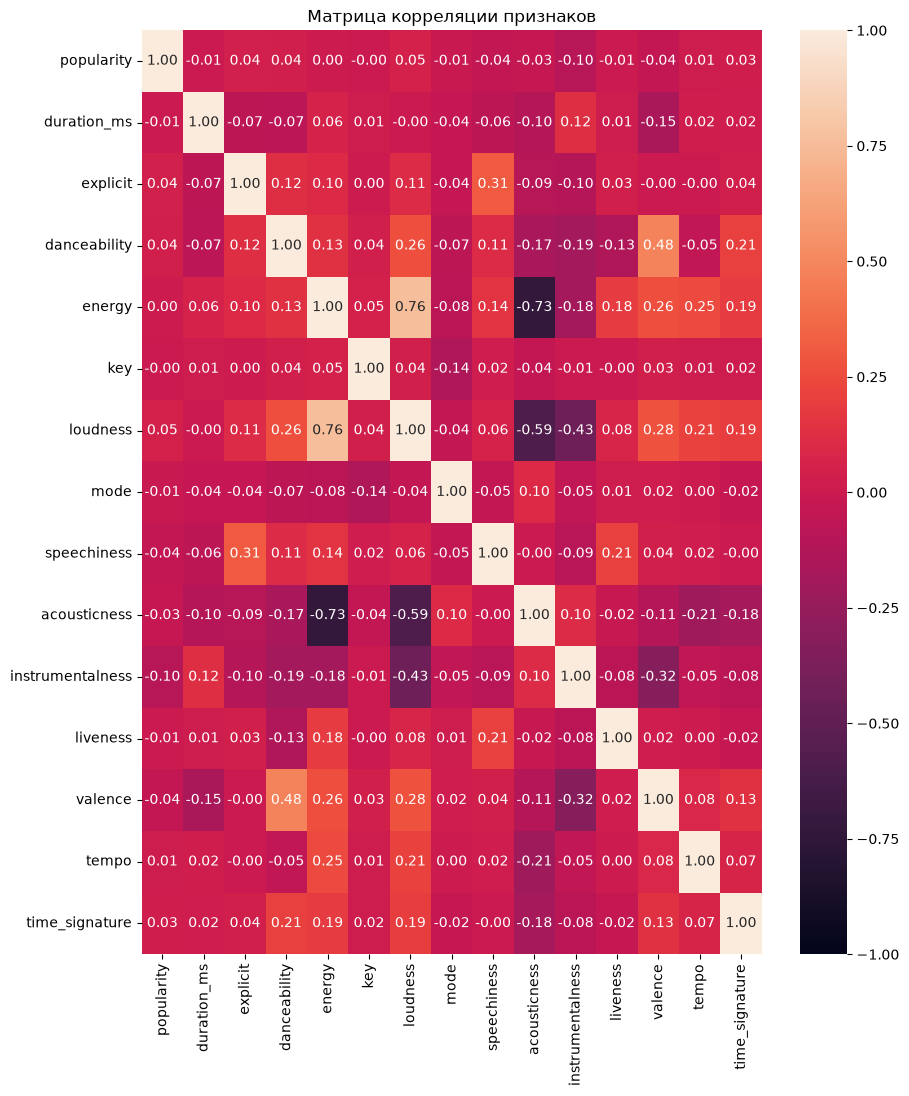

In [144]:
# Матрица корреляций 
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

In [228]:
display(df.nunique())
display(df.info())

popularity            101
duration_ms         50697
explicit                2
danceability         1174
energy               2083
key                    12
loudness            19480
mode                    2
speechiness          1489
acousticness         5061
instrumentalness     5346
liveness             1722
valence              1790
tempo               45653
time_signature          5
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   popularity        114000 non-null  int64  
 1   duration_ms       114000 non-null  int64  
 2   explicit          114000 non-null  int64  
 3   danceability      114000 non-null  float64
 4   energy            114000 non-null  float64
 5   key               114000 non-null  int64  
 6   loudness          114000 non-null  float64
 7   mode              114000 non-null  int64  
 8   speechiness       114000 non-null  float64
 9   acousticness      114000 non-null  float64
 10  instrumentalness  114000 non-null  float64
 11  liveness          114000 non-null  float64
 12  valence           114000 non-null  float64
 13  tempo             114000 non-null  float64
 14  time_signature    114000 non-null  int64  
dtypes: float64(9), int64(6)
memory usage: 13.0 MB


None

**Кодировние**

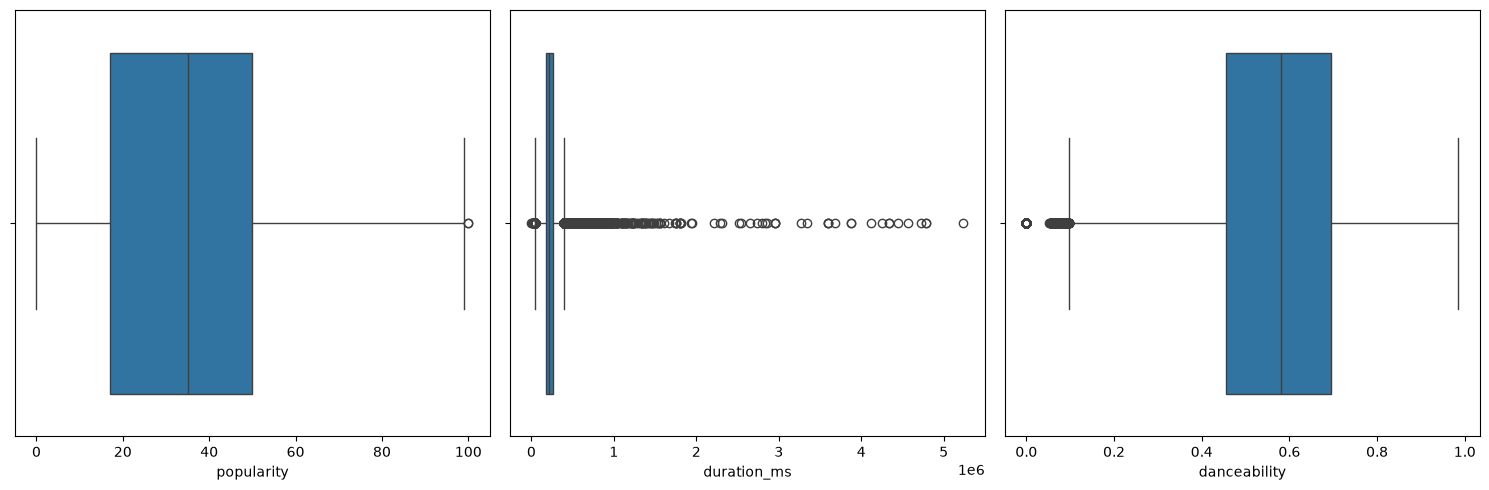

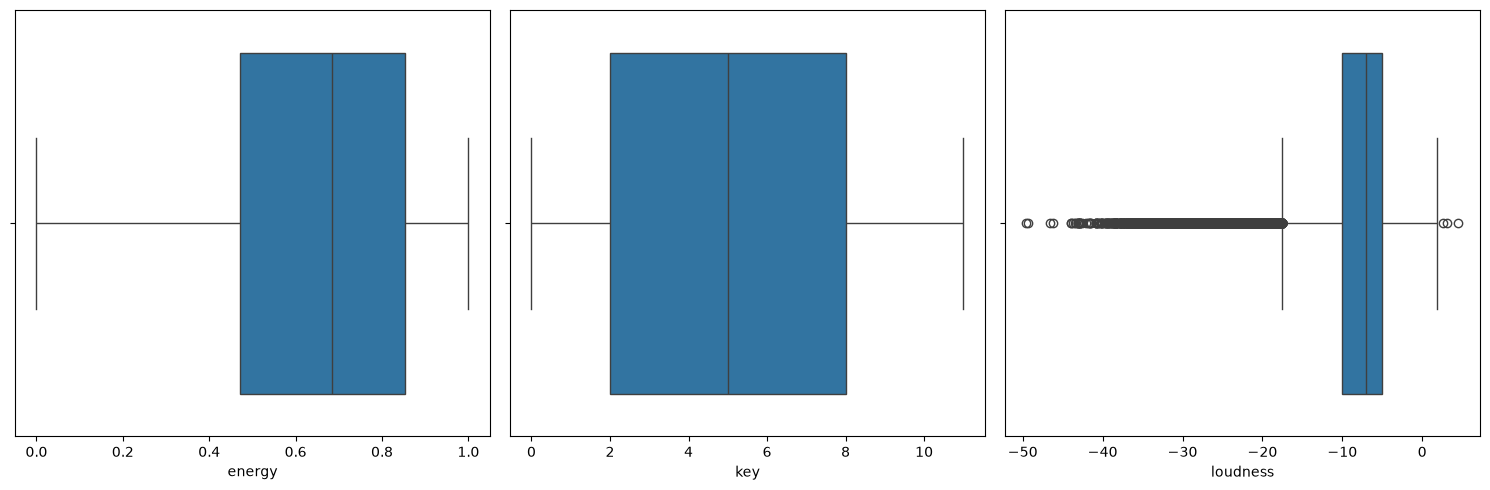

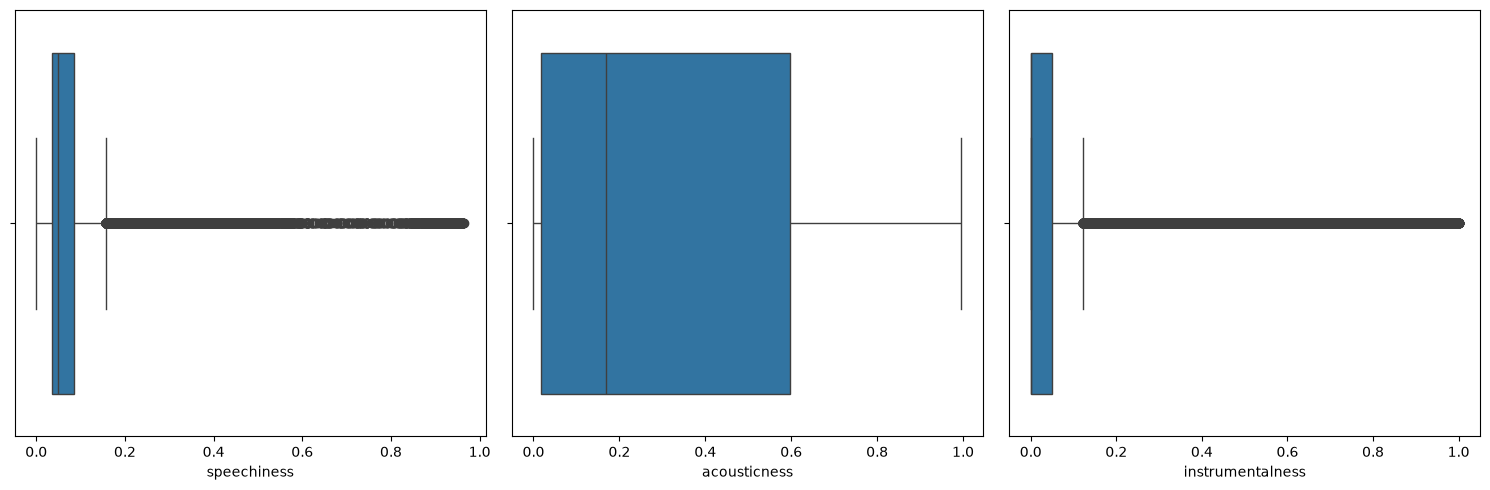

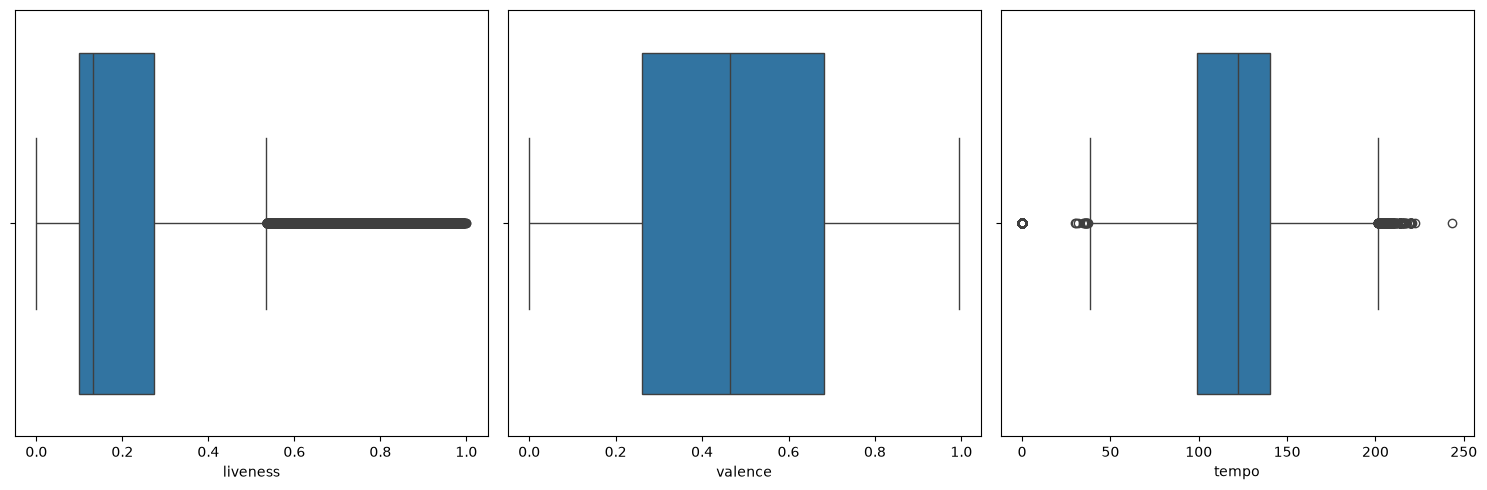

In [ ]:
excl = ['explicit', 'key', 'mode', 'time_signature']
numeric_columns = [k for k in df.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5))
    for j in range(tmp):
        sns.boxplot(data=df, x=df[numeric_columns[i + j]], ax=axes[j])
    i = i + tmp

    plt.tight_layout()
    plt.show()


Также выброшу данные, у которых duration_ms > 1000 * 60 * 10 (10 минут) или duration_ms < 1000 * 30 (30 секунд), потому что вряд-ли это будут песни

Удалю то, что по громкости ниже -25 дб, ибо это скорее всего аудиокниги либо какие-то звуки природы. И удалю записи с околонулевым темпом

In [229]:
df = df[(1000 * 30 < df['duration_ms']) & (df['duration_ms'] < 1000 * 60 * 10) ]
df = df[df['loudness'] >= -25]
df = df[df['tempo'] >= 1]

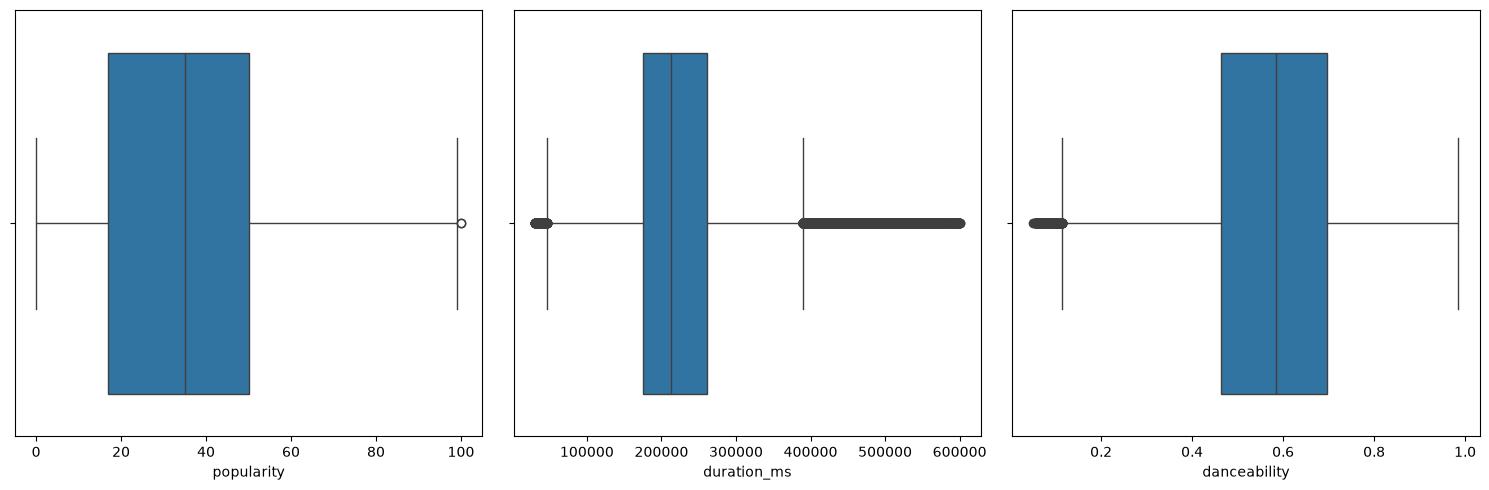

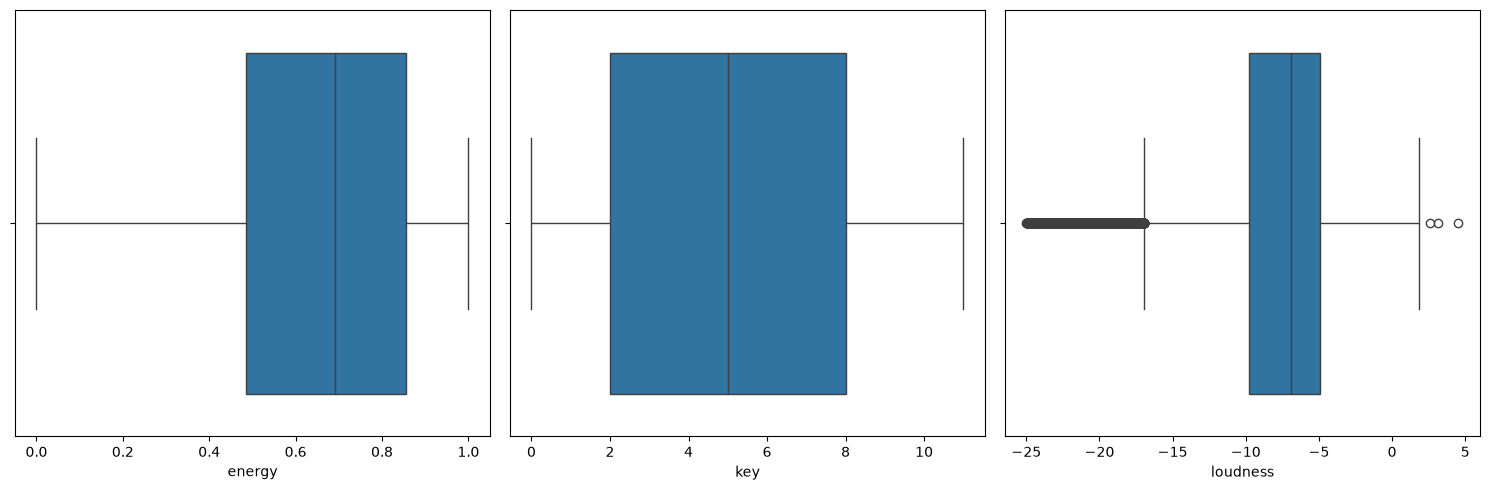

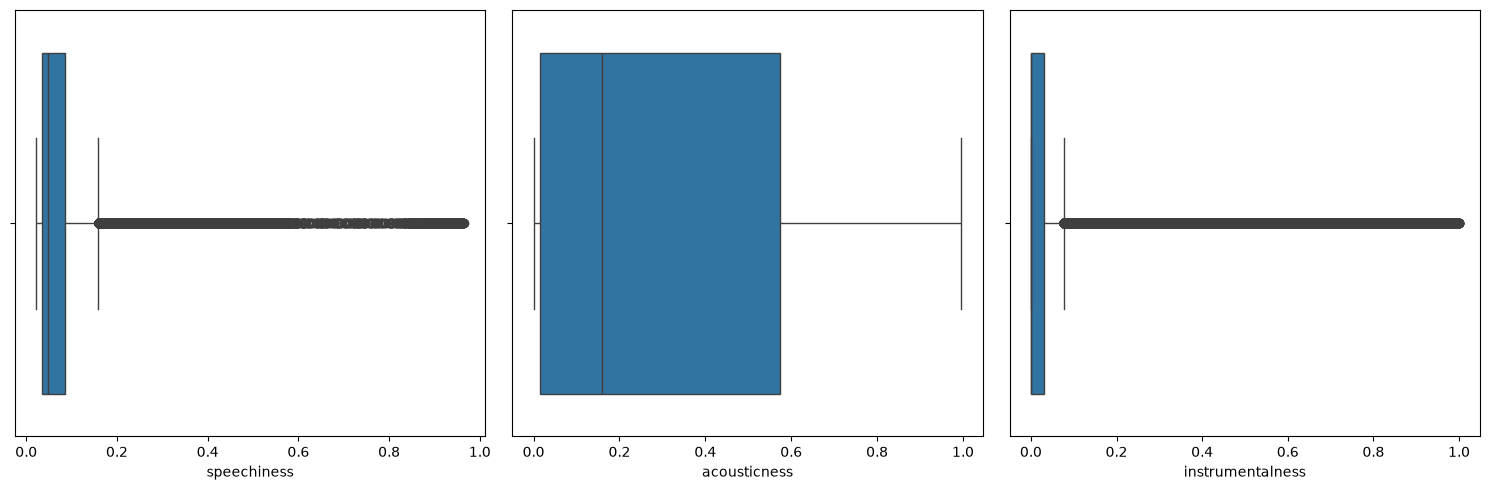

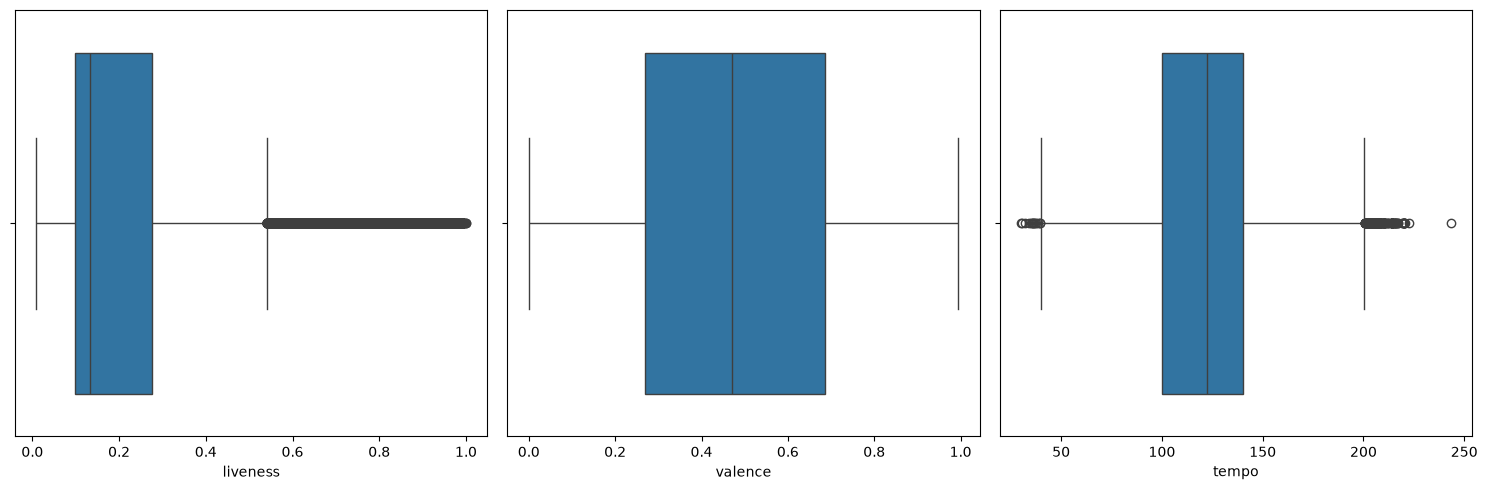

In [ ]:
excl = ['explicit', 'key', 'mode', 'time_signature']
numeric_columns = [k for k in df.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5))
    for j in range(tmp):
        sns.boxplot(data=df, x=df[numeric_columns[i + j]], ax=axes[j])
    i = i + tmp

    plt.tight_layout()
    plt.show()


Преобразования: \
    **popularity** : std (нет выбросов, почти симметрия) \
    **duration_ms** :  robust (есть выбросы, почти симметрия)\
    **danceability** : robust (есть выбросы, есть симметрия)\
    **energy** : std (нет выбросов, почти симметрия)\
    **loudness** : robust (есть выбросы, почти симметрия)\
    **speechiness** : QuantileTransform (длинный хвост выбросов, сильная ассиметрия)\
    **acousticness** : QuantileTransform (выбросов нет, ассиметрия)\
    **instrumentalness** : QuantileTransform (длинный хвост выбросов, сильная ассиметрия)\
    **liveness** : QuantileTransform (длинный хвост выбросов, ассиметрия)\
    **valence** : std (нет выбросов, симметрия)\
    **tempo** : robust (есть выбросы, симметрия)



In [230]:
display(df['time_signature'].value_counts())
display(df['key'].value_counts())

time_signature
4    100322
3      8572
5      1663
1       877
0         4
Name: count, dtype: int64

key
7     12974
0     12716
2     11346
9     11086
1     10508
11     9180
5      9141
4      8815
6      7786
10     7256
8      7211
3      3419
Name: count, dtype: int64

Кодирование: \
    **key** циклическое кодирование через синус и косинус; \
    **time_signature** Удалю строки со значением time_signature = 0, это видимо какие-то помехи.\
    90% значений этого признака, это 4, поэтому использую бинарное кодирование : 4-> 1, !4 -> 0

In [231]:
df = df[df['time_signature'] != 0]

In [232]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler, OneHotEncoder, FunctionTransformer

In [233]:
def sin_cos_transformer(x, period):
    x = np.asarray(x)
    sin_key = np.sin(2 * np.pi * x / period)
    cos_key = np.cos(2 * np.pi * x / period)
    return np.column_stack([sin_key, cos_key])

def get_sin_cos_names(transformer, input_features):
    names = []
    for col in input_features:
        names.extend([f"{col}_sin", f"{col}_cos"])
    return names

key_transformer = FunctionTransformer(sin_cos_transformer, kw_args={'period':12}, feature_names_out=get_sin_cos_names)

In [234]:
def bin_time_signature(x):
    x = np.asarray(x)
    x = np.where(x == 4, 1, 0)
    return x.reshape(-1, 1)

time_signature_transformer = FunctionTransformer(bin_time_signature, feature_names_out = lambda self, in_feat: ['time_signature'])

In [235]:
ct = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['popularity', 'energy', 'valence']),      
        ('quantile', QuantileTransformer(output_distribution='normal', random_state=42), ['speechiness', 'acousticness', 'instrumentalness', 'liveness']),    
        ('robust', RobustScaler(), ['duration_ms', 'danceability', 'loudness', 'tempo']),
        ('key_cyclical', key_transformer, ['key']),
        ('bin', time_signature_transformer, ['time_signature'])
    ],
    remainder='passthrough'
)

In [236]:
transformed_arr = ct.fit_transform(df)

In [237]:
feature_names = ct.get_feature_names_out()
df_transformed = pd.DataFrame(transformed_arr, columns=feature_names)

In [238]:
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 111434 entries, 0 to 111433
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   std__popularity             111434 non-null  float64
 1   std__energy                 111434 non-null  float64
 2   std__valence                111434 non-null  float64
 3   quantile__speechiness       111434 non-null  float64
 4   quantile__acousticness      111434 non-null  float64
 5   quantile__instrumentalness  111434 non-null  float64
 6   quantile__liveness          111434 non-null  float64
 7   robust__duration_ms         111434 non-null  float64
 8   robust__danceability        111434 non-null  float64
 9   robust__loudness            111434 non-null  float64
 10  robust__tempo               111434 non-null  float64
 11  key_cyclical__key_sin       111434 non-null  float64
 12  key_cyclical__key_cos       111434 non-null  float64
 13  bin__time_signature      

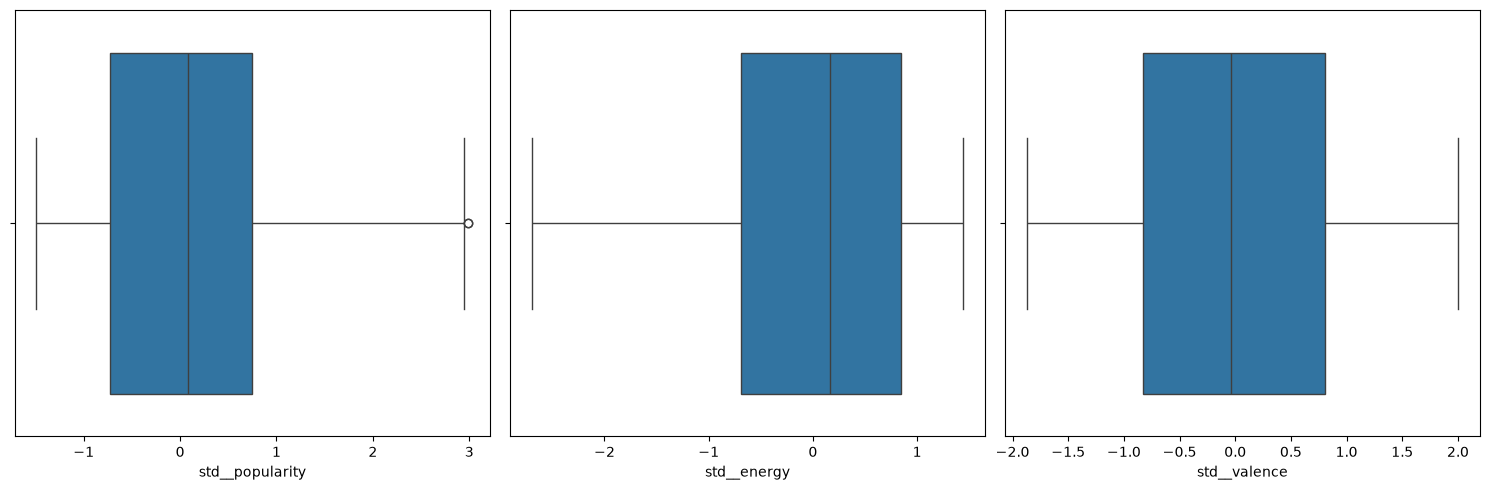

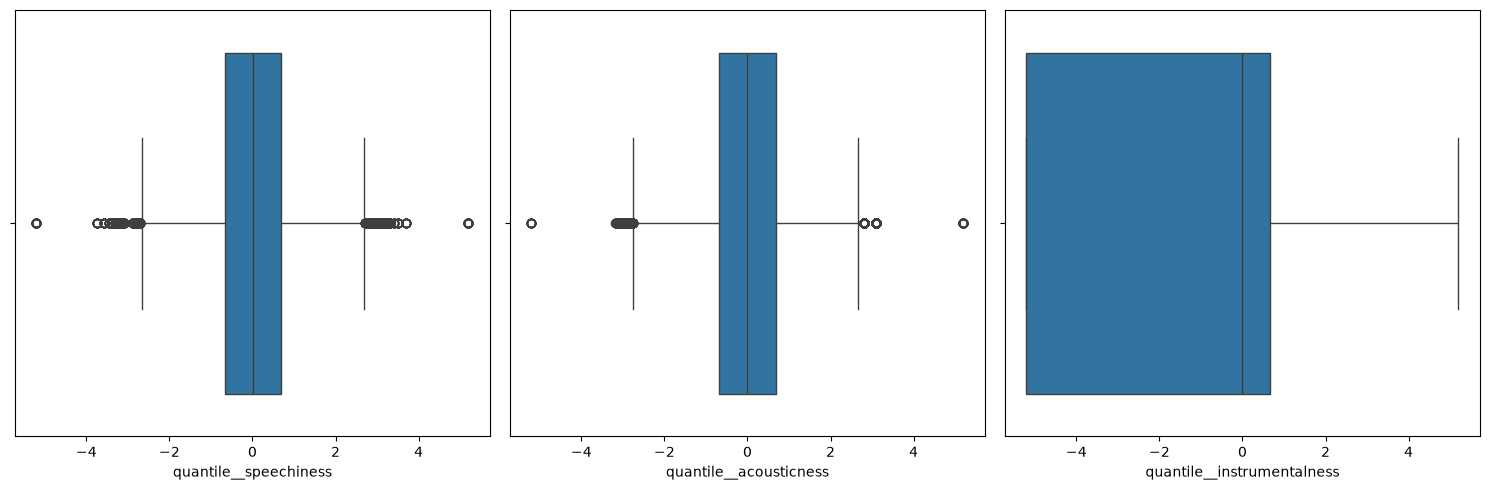

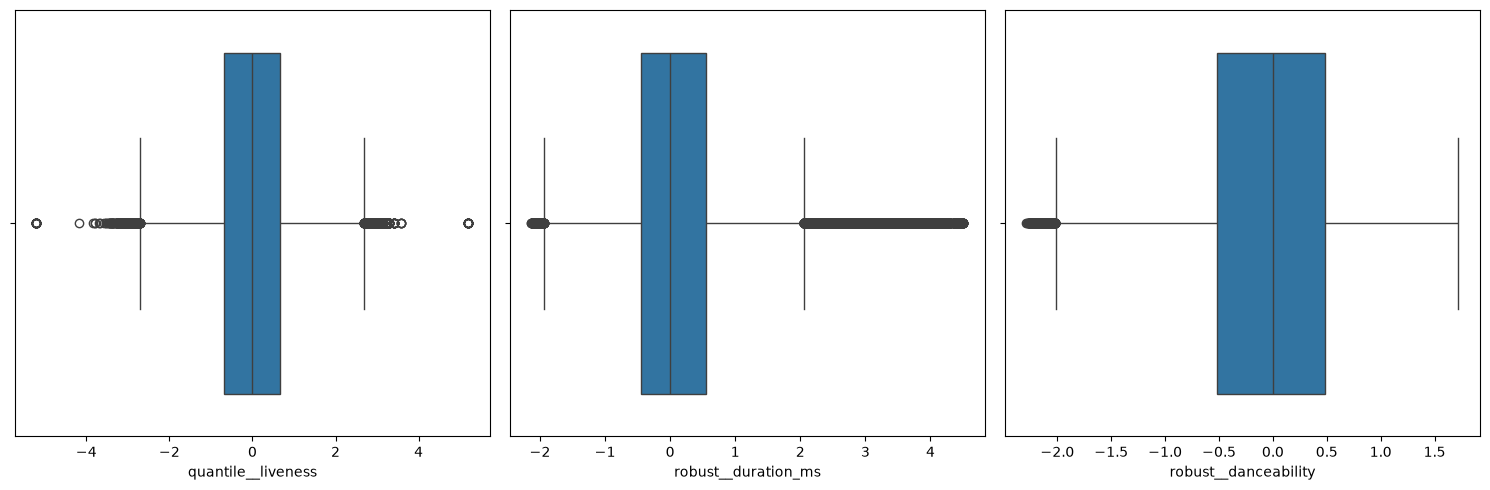

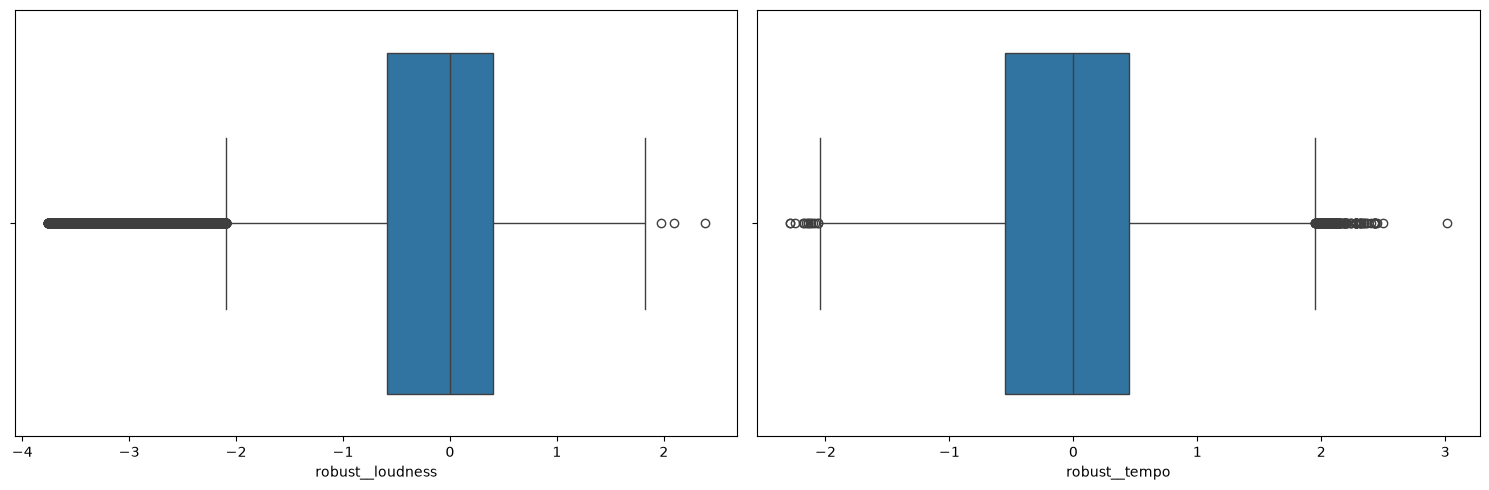

In [239]:
excl = ['key_cyclical__key_sin', 'key_cyclical__key_cos', 'bin__time_signature', 'remainder__explicit', 'remainder__mode']
numeric_columns = [k for k in df_transformed.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5), squeeze=False)
    for j in range(tmp):
        sns.boxplot(data=df, x=df_transformed[numeric_columns[i + j]], ax=axes[0, j])
    i = i + tmp

    plt.tight_layout()
    plt.show()

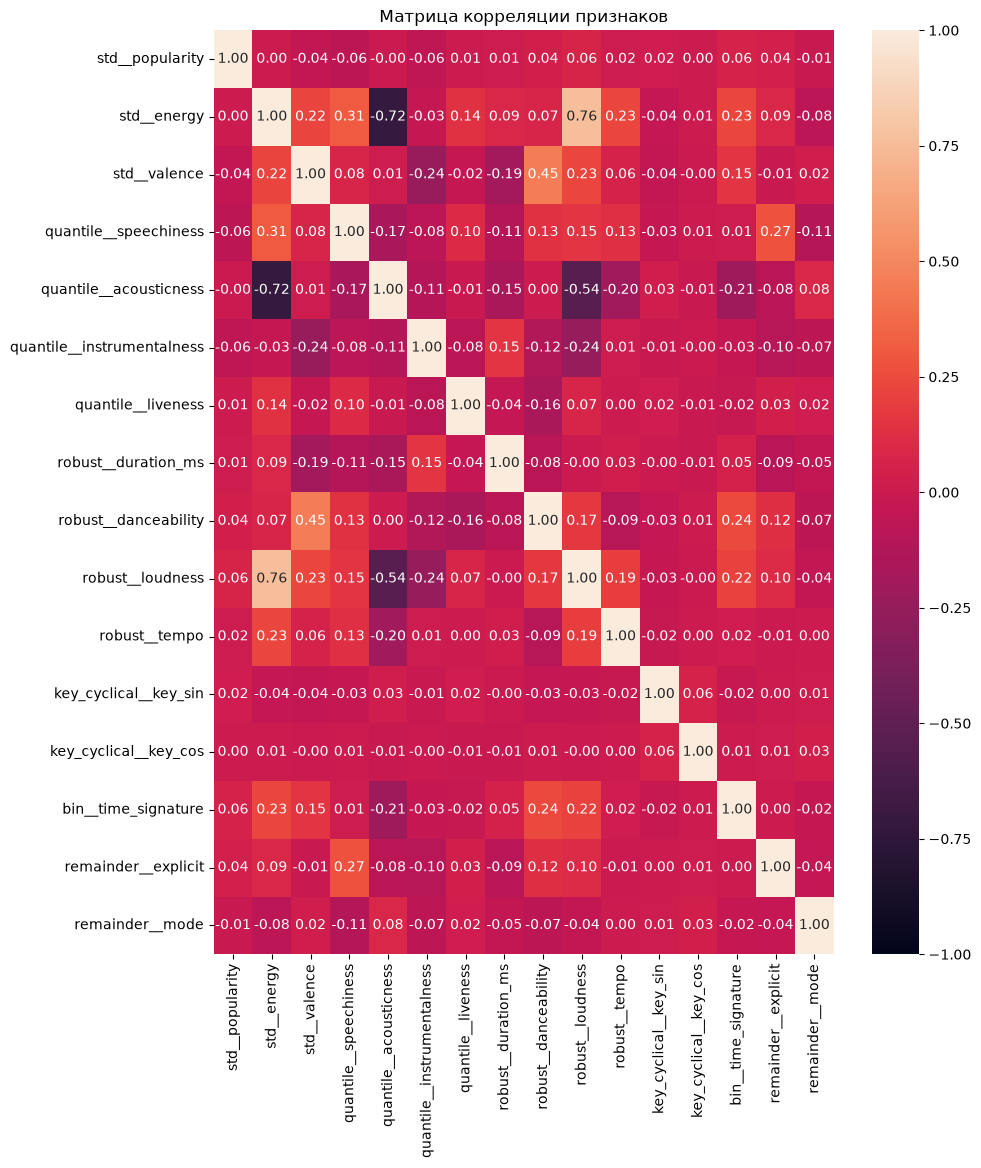

In [240]:
# Матрица корреляций после нелинейных преобразований
corr_matrix = df_transformed.corr(numeric_only=True)
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

In [241]:
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 111434 entries, 0 to 111433
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   std__popularity             111434 non-null  float64
 1   std__energy                 111434 non-null  float64
 2   std__valence                111434 non-null  float64
 3   quantile__speechiness       111434 non-null  float64
 4   quantile__acousticness      111434 non-null  float64
 5   quantile__instrumentalness  111434 non-null  float64
 6   quantile__liveness          111434 non-null  float64
 7   robust__duration_ms         111434 non-null  float64
 8   robust__danceability        111434 non-null  float64
 9   robust__loudness            111434 non-null  float64
 10  robust__tempo               111434 non-null  float64
 11  key_cyclical__key_sin       111434 non-null  float64
 12  key_cyclical__key_cos       111434 non-null  float64
 13  bin__time_signature      